Install Libraries that are necessary for Quantum Circuit to Run on Colab

In [7]:
!pip install qiskit

After the new version of qiskit is out, we need to install aer simulator separately

In [8]:
!pip install qiskit qiskit-aer

Now we will run this quantum circuit to find the secret code

Secret string: 10110
Number of qubits needed: 5

Added CNOT from q[0] to auxiliary q[5]
Added CNOT from q[2] to auxiliary q[5]
Added CNOT from q[3] to auxiliary q[5]
Raw Qiskit output (q[0] is RIGHTMOST bit): {'01101': 1024}

Raw output (Qiskit order): 01101
Reversed (the order I wanted): 10110

 SUCCESS! The quantum computer found your secret!


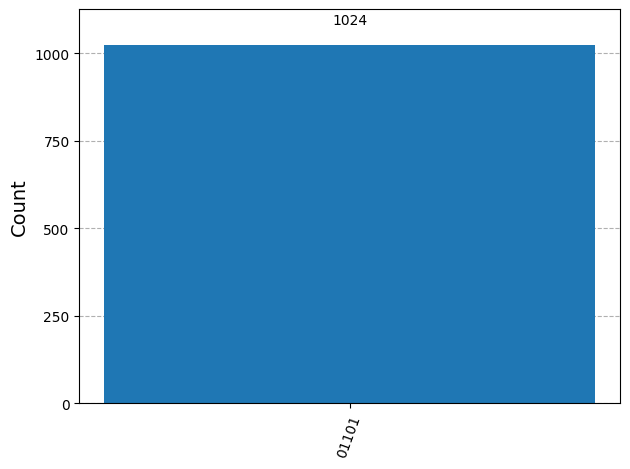

In [9]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

#our SETUP
secret_string = '10110'  # you can change this secret code.
n = len(secret_string)

print(f"Secret string: {secret_string}")
print(f"Number of qubits needed: {n}")
print()

# Building the circuit
qc = QuantumCircuit(n+1, n)

# Step A: X on auxiliary qubit (the last one)
qc.x(n)

# Step B: Hadamard on ALL qubits
for i in range(n+1):
    qc.h(i)

# Step C: add CNOT for each '1' in secret string
for i in range(n):
    if secret_string[i] == '1':
        qc.cx(i, n)
        print(f"Added CNOT from q[{i}] to auxiliary q[{n}]")

# Step D: Hadamard on input qubits only
for i in range(n):
    qc.h(i)

# Step E: Measure input qubits
for i in range(n):
    qc.measure(i, i)

# --- RUN THE CIRCUIT ---
simulator = Aer.get_backend('qasm_simulator')
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(qc)

print("Raw Qiskit output (q[0] is RIGHTMOST bit):", counts)

# Find the most common result and reverse it (Qiskit uses little-endian)
raw_result = max(counts, key=counts.get)
reversed_result = raw_result[::-1]

print(f"\nRaw output (Qiskit order): {raw_result}")
print(f"Reversed (the order I wanted): {reversed_result}")

if reversed_result == secret_string:
    print("\n SUCCESS! The quantum computer found your secret!")
else:
    print(f"\n Something's off. Expected {secret_string}, got {reversed_result}")

# Optional: Show histogram
plot_histogram(counts)